In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = pd.read_csv('winequality-red.csv')

In [4]:
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


## check outliers

In [6]:
def checkOutliers(data, col):
    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.boxplot(data[col])
    plt.title(f'boxplot of {col}')

    plt.subplot(1,2,2)
    sns.histplot(data=data, x=col, kde=True)
    
    mean = data[col].mean()
    std = data[col].std()

    plt.axvline(mean + 3*std, color='red')
    plt.axvline(mean - 3*std, color='red')

    plt.tight_layout()
    plt.show()

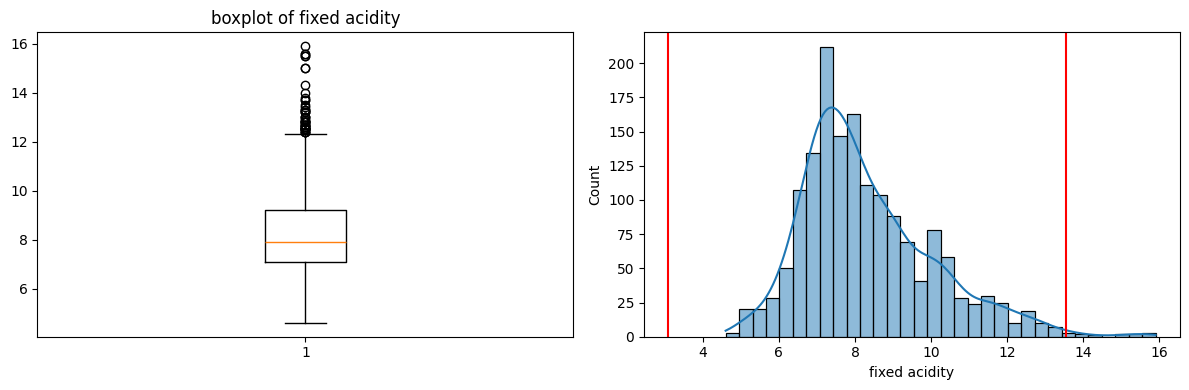

In [7]:
checkOutliers(data, 'fixed acidity')

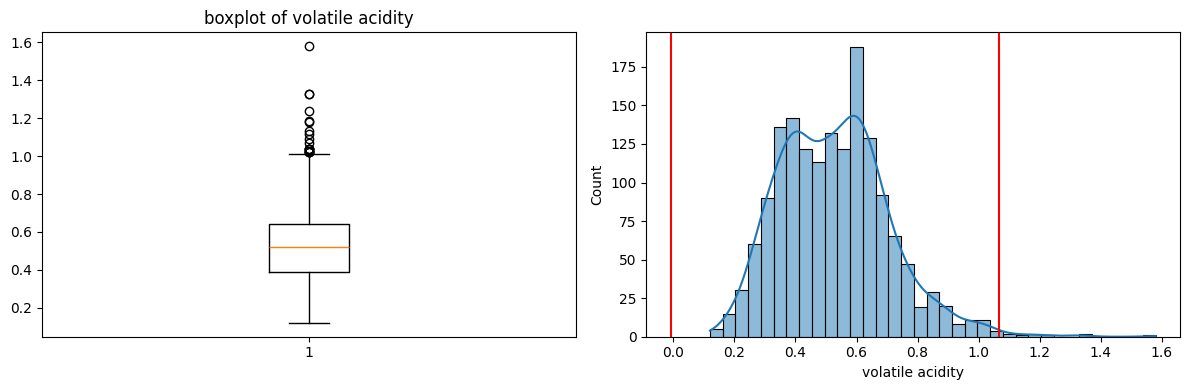

In [8]:
checkOutliers(data, 'volatile acidity')

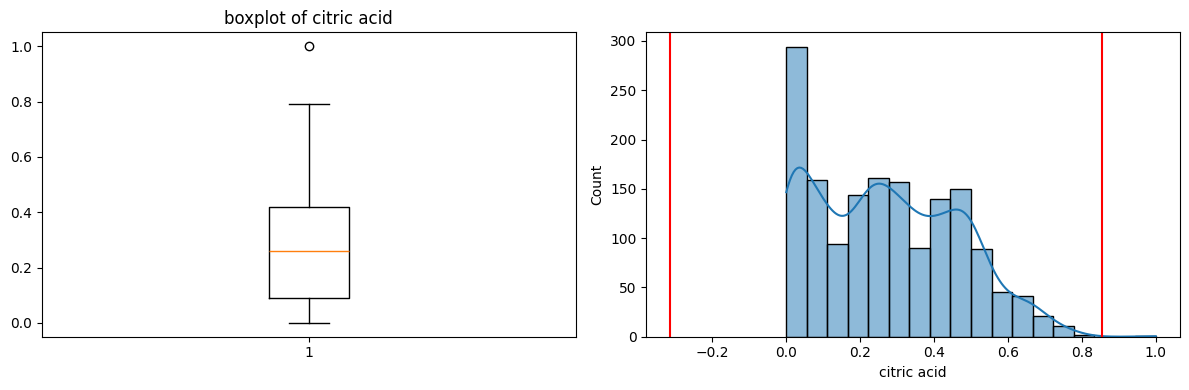

In [9]:
checkOutliers(data, 'citric acid')

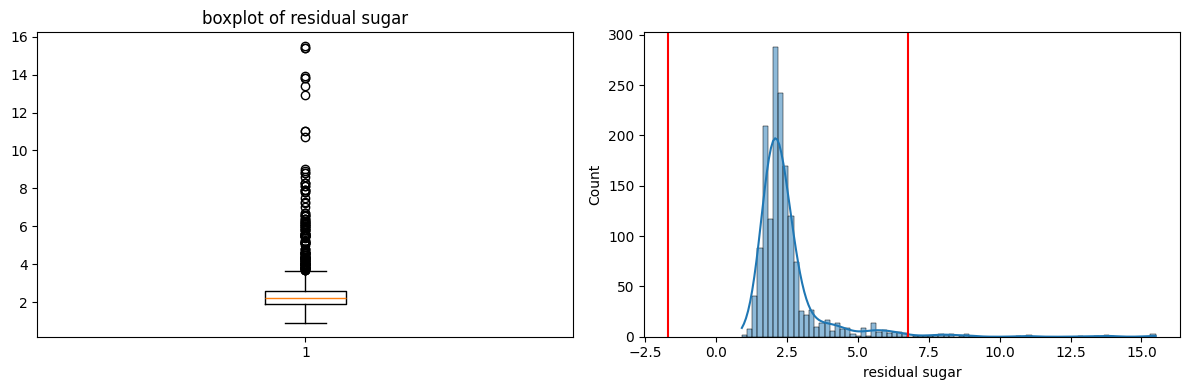

In [10]:
checkOutliers(data, 'residual sugar')

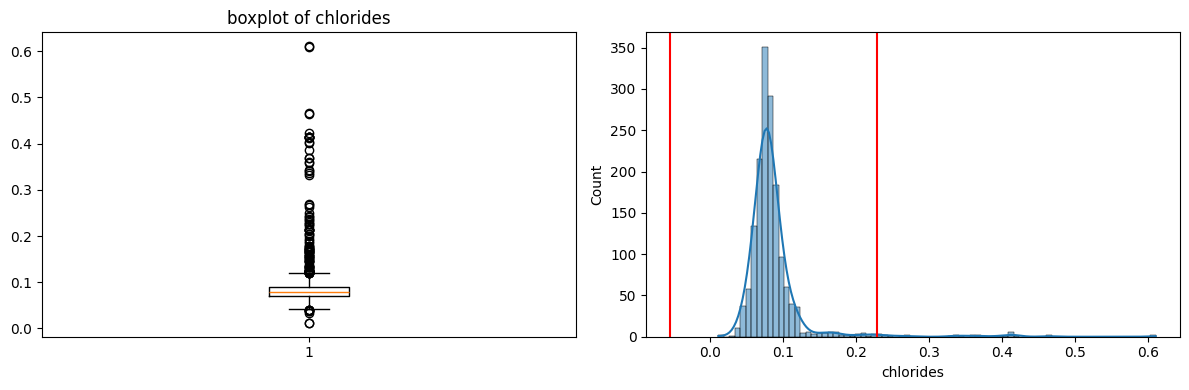

In [11]:
checkOutliers(data, 'chlorides')

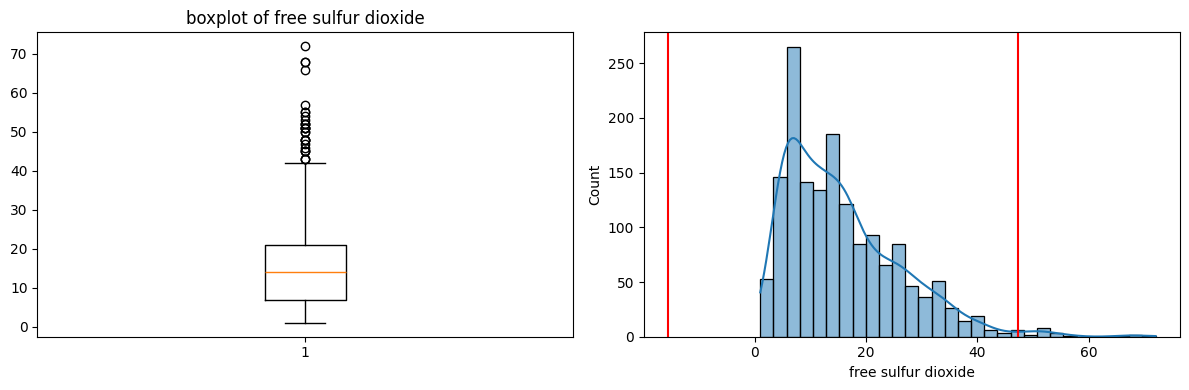

In [12]:
checkOutliers(data, 'free sulfur dioxide')

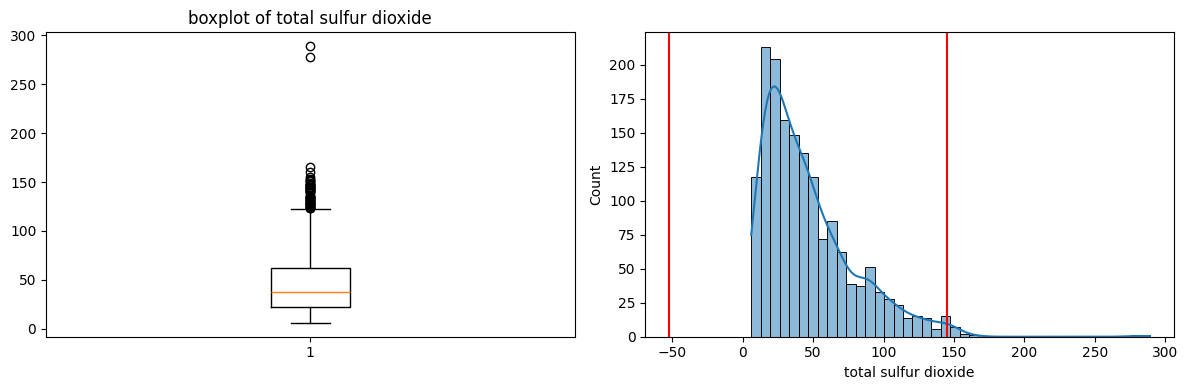

In [13]:
checkOutliers(data, 'total sulfur dioxide')

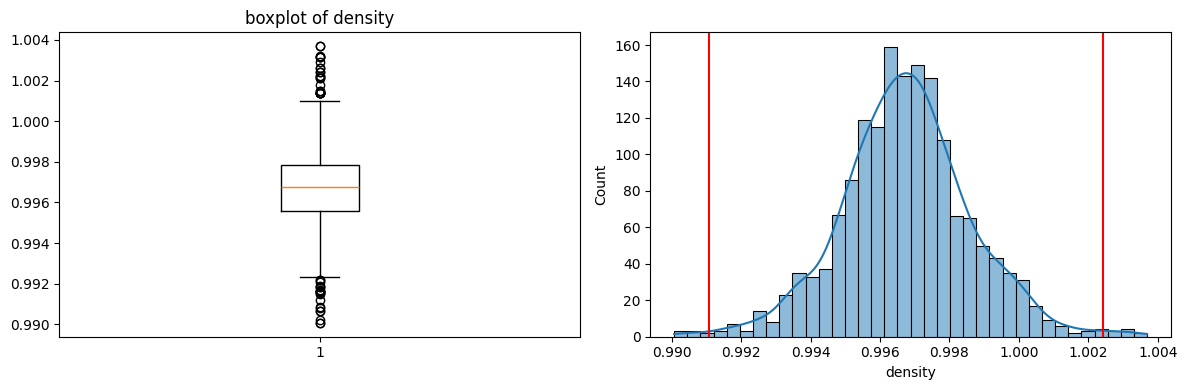

In [14]:
checkOutliers(data, 'density')

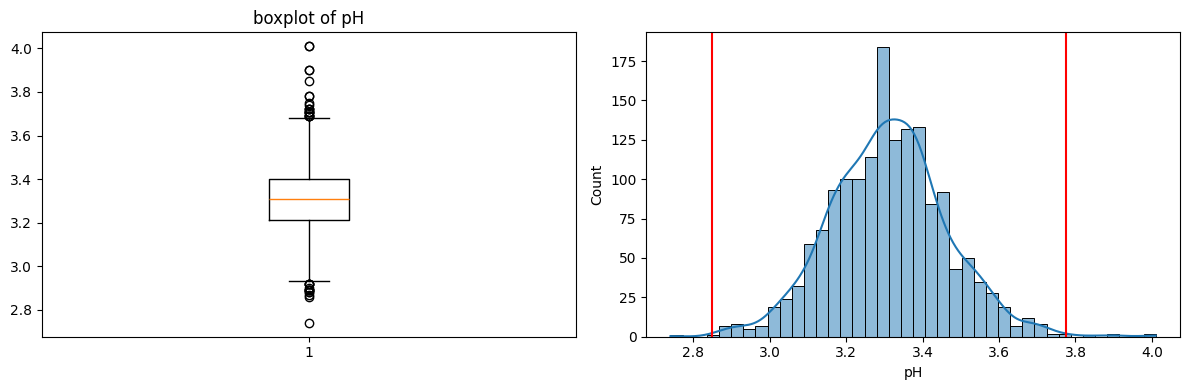

In [15]:
checkOutliers(data, 'pH')

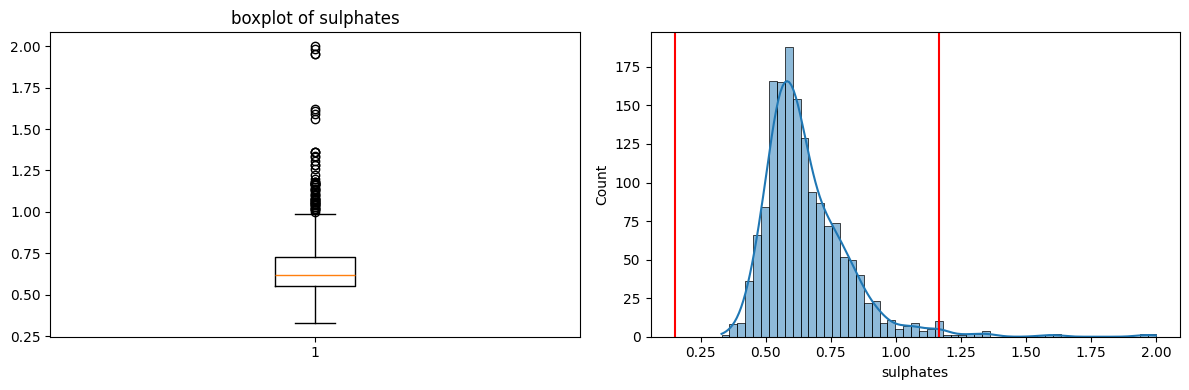

In [16]:
checkOutliers(data, 'sulphates')

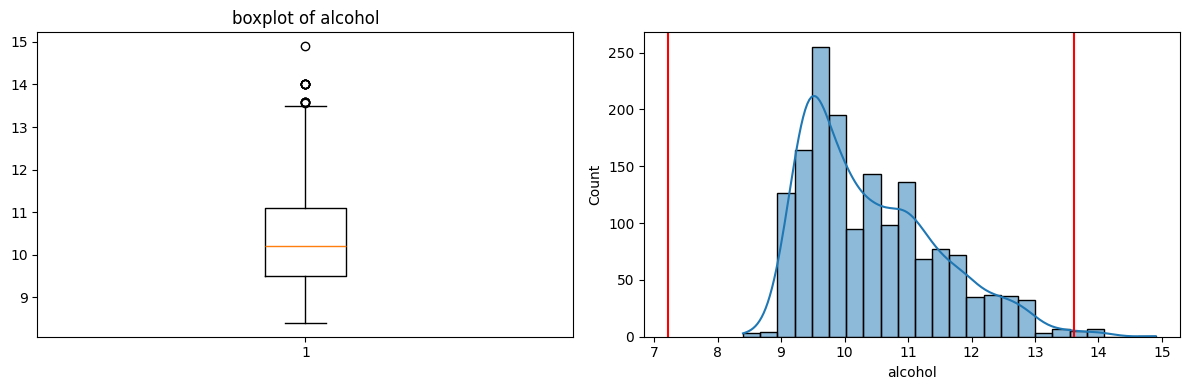

In [17]:
checkOutliers(data, 'alcohol')

In [18]:
data['quality'].unique()

array([5, 6, 7, 4, 8, 3])

In [19]:
data['quality'].value_counts()

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64

## Correlation

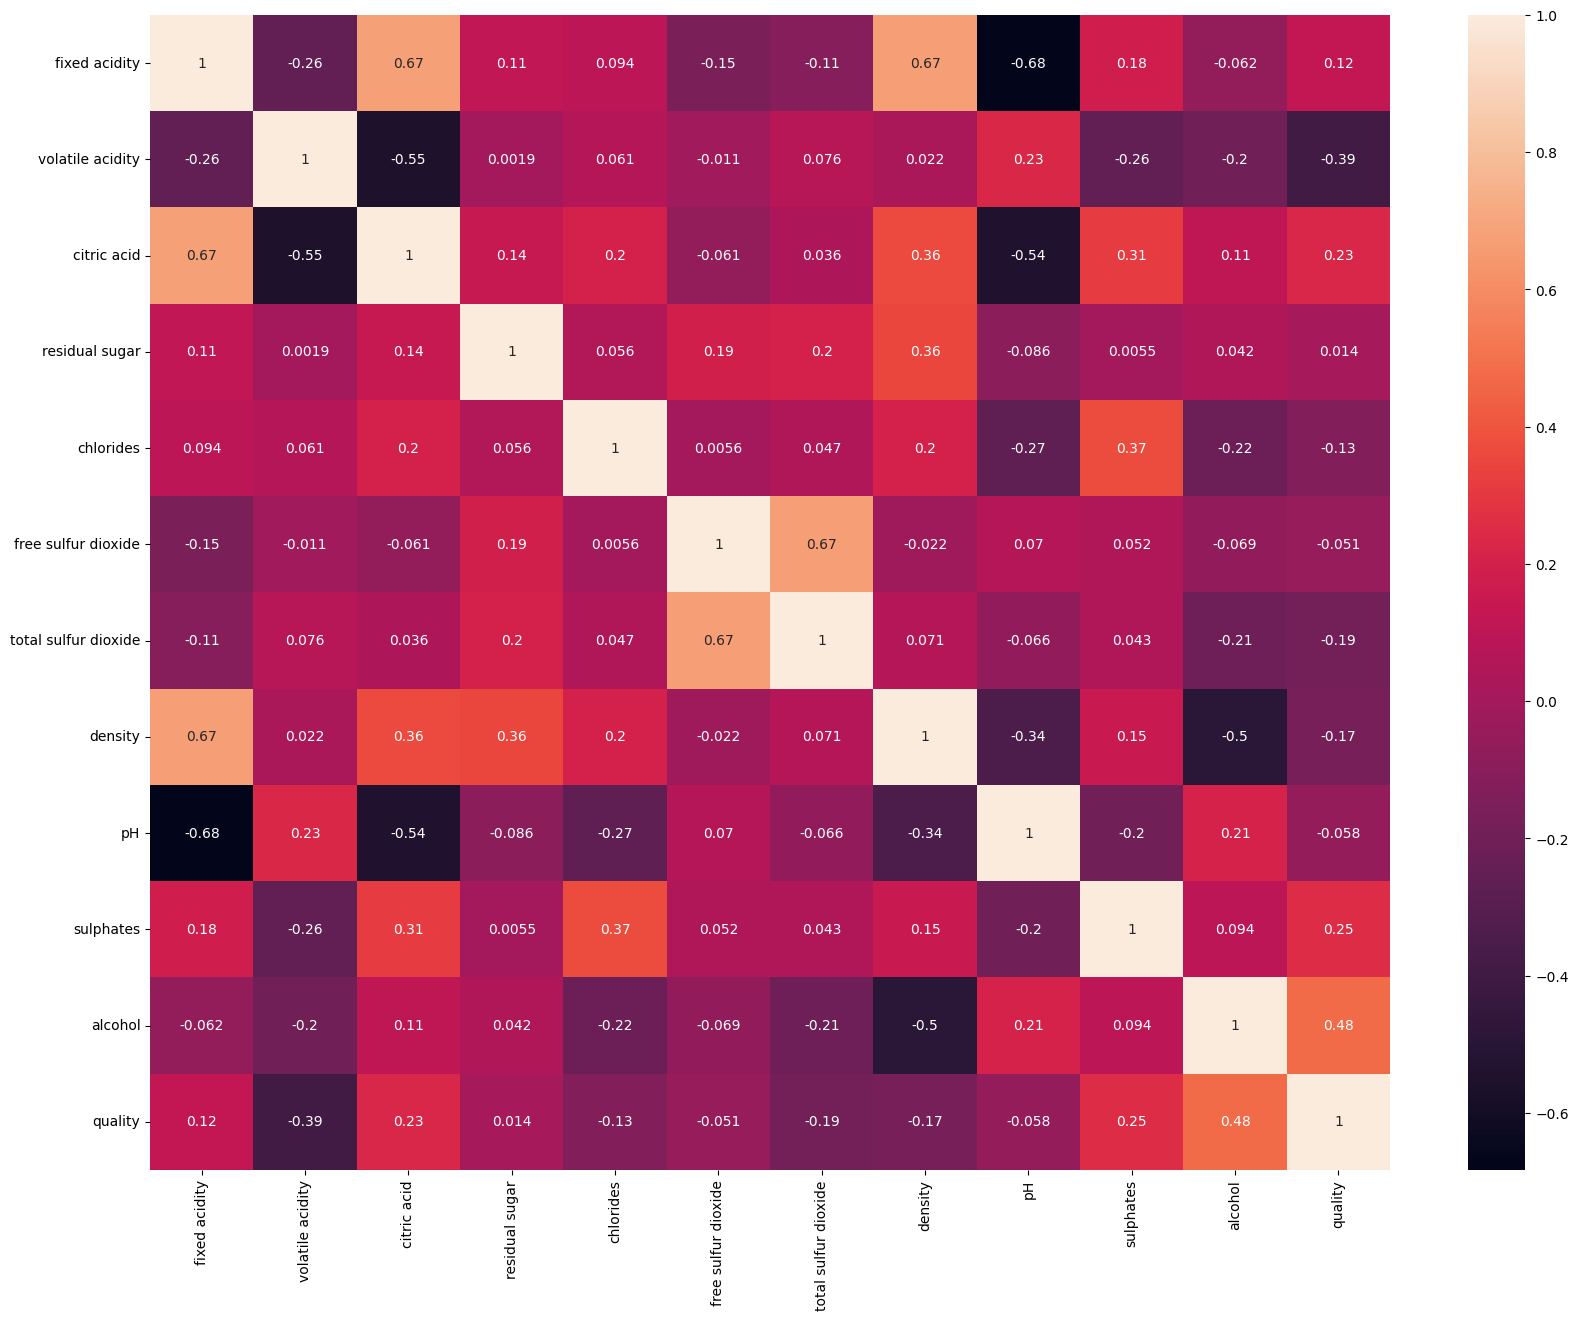

In [20]:
plt.figure(figsize=(20,15))
sns.heatmap(data.corr(), annot=True)
plt.show()

## checking VIF

In [21]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [22]:
def calculatVIF(data):
    vif = []
    output = pd.DataFrame()
    output['Attripute'] = data.columns
    for i in range(0, data.shape[1]):
        vif.append(variance_inflation_factor(data, i))
    output['VIF'] = vif
    return output

In [23]:
X = data.drop('quality', axis=1)
y = data['quality'].apply(lambda y_value: 1 if y_value>=7 else 0)

In [24]:
calculatVIF(X)

,Attripute,VIF
0,fixed acidity,74.452265
1,volatile acidity,17.060026
2,citric acid,9.183495
3,residual sugar,4.662992
4,chlorides,6.554877
5,free sulfur dioxide,6.442682
6,total sulfur dioxide,6.519699
7,density,1479.287209
8,pH,1070.967685
9,sulphates,21.590621


In [25]:
from imblearn.over_sampling import SMOTE
sm = SMOTE()

In [26]:
X_sm, y_sm = sm.fit_resample(X, y)

print("Before SMOTE:")
print(y.value_counts())

print("After SMOTE:")
print(y_sm.value_counts())

Before SMOTE:
quality
0    1382
1     217
Name: count, dtype: int64
After SMOTE:
quality
0    1382
1    1382
Name: count, dtype: int64


In [27]:
from sklearn.model_selection import train_test_split

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X_sm, y_sm, test_size=0.3, random_state=42)

## Random Forest

In [29]:
from sklearn.ensemble import RandomForestClassifier

In [30]:
from sklearn.model_selection import cross_validate

In [31]:
rf = RandomForestClassifier(criterion='gini', n_estimators=400)
result = cross_validate(rf, X_train, y_train)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",400
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [32]:
result['test_score'].mean()

np.float64(0.9322729646142106)

In [33]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
test_pred = rf.predict(X_test)
accuracy_score(y_test, test_pred)

0.9325301204819277

In [34]:
confusion_matrix(y_test, test_pred)

array([[389,  46],
       [ 10, 385]])

In [35]:
print(classification_report(y_test,test_pred))

              precision    recall  f1-score   support

           0       0.97      0.89      0.93       435
           1       0.89      0.97      0.93       395

    accuracy                           0.93       830
   macro avg       0.93      0.93      0.93       830
weighted avg       0.94      0.93      0.93       830



In [41]:
import joblib
joblib.dump(rf, "wine_quality_model.pkl")

['wine_quality_model.pkl']

In [40]:
input_data = (7.5,0.5,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.8,10.5)
# input_data = (9.5, 0.56, 0.33, 2.4, 0.08900000000000001, 35.0, 67.0, 0.9972, 3.28, 0.73, 11.8)


input_data_as_numpy_array = np.asarray(input_data)


input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

prediction = rf.predict(input_data_reshaped)
print(prediction)

if (prediction[0]==1):
  print('Good Quality Wine')
else:
  print('Bad Quality Wine')

[1]
Good Quality Wine


D:\Python\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
